In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
data = pd.read_csv("./input/country_results.csv")

Os dados com que estamos trabalhando referem-se aos resultados de cada país participante da Olimpíada Internacional de Matemática (IMO) ao longo dos anos de 1959 - 2024. Cada linha da tabela abaixo traz informações sobre a participação de um país em uma edição específica da competição. Cada coluna representa um possível dado nesse contexto, sendo eles: 
- ano da edição (year): variável numérica discreta;
- país participante (country): variável categórica nominal;
- quantidade de participantes da equipe (team_size_all): variável numérica discreta;
- quantidade de participantes masculinos da equipe (team_size_male): variável numérica discreta;
- quantidade de participantes femininos da equipe (team_size_female): variável numérica discreta;
- pontuação acumulada da equipe em cada problema respectivo da prova (p1, p2, ..., p7): variável numérica discreta;
- quantidade de medalhas de ouro, prata ou bronze e quantidade de menções honrosas conferidas à equipe (awards_gold, awards_silver, awards_bronze, awards_honorable_mentions): variável numérica discreta;
- nome completo do líder da equipe (leader): variável categórica nominal;
- nome completo do vice-líder da equipe (deputy_leader): variável categórica nominal.


Valores com informações faltantes são marcadas com "NA".

In [20]:
display(data)

,year,country,team_size_all,team_size_male,team_size_female,p1,p2,p3,p4,p5,p6,p7,awards_gold,awards_silver,awards_bronze,awards_honorable_mentions,leader,deputy_leader
0,2024,United States of America,6,5.0,1.0,42.0,41.0,19.0,40.0,35.0,15.0,NaN,5.0,1.0,0.0,0.0,John Berman,Carl Schildkraut
1,2024,People's Republic of China,6,6.0,0.0,42.0,42.0,31.0,40.0,22.0,13.0,NaN,5.0,1.0,0.0,0.0,Liang Xiao,Yijun Yao
2,2024,Republic of Korea,6,6.0,0.0,42.0,37.0,18.0,42.0,7.0,22.0,NaN,2.0,4.0,0.0,0.0,Suyoung Choi,Hwajong Yoo
3,2024,India,6,6.0,0.0,42.0,34.0,11.0,42.0,28.0,10.0,NaN,4.0,1.0,0.0,1.0,Krishnan Sivasubramanian,Rijul Saini
4,2024,Belarus,6,6.0,0.0,42.0,30.0,10.0,42.0,36.0,5.0,NaN,4.0,0.0,2.0,0.0,David Zmiaikou,Dzmitry Bazyleu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3775,1959,Czechoslovakia,8,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,NaN,Rudolf Zelinka,NaN
3776,1959,Bulgaria,8,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,Stoian Budurov,NaN
3777,1959,Poland,8,7.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,Mieczyslaw Czyżykowski,NaN
3778,1959,Union of Soviet Socialist Republics,4,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,Anatol Mikhailovitch Vladimirski,NaN


A fim de possuirmos variáveis de todos os 4 tipos possíveis para esse estudo, iremos derivar duas novas variáveis a partir desses dados:
- proporção de participantes femininos na equipe (female_proportion): variável numérica contínua;
- maturidade da equipe em concentrar-se somente nas fáceis ou garantir pontos nas difíceis (team_approach): variável categórica ordinal.

In [21]:
data["female_proportion"] = data["team_size_female"]/data["team_size_all"]

max = 7*data["team_size_all"]*2
p_easy = (data["p1"]+data["p4"])/max
p_medium = (data["p2"]+data["p5"])/max
p_hard = (data["p3"]+data["p6"])/max

thresholds = [
    (p_easy >= 0.8) & (p_medium >= 0.5) & (p_hard >= 0.2),
    (p_easy >= 0.8) & (p_medium >= 0.5),
    (p_easy >= 0.8),
    (p_easy < 0.8)
]

values = ["Elite", "Regular", "Base", "Incomplete Base"]

data["team_approach"] = pd.Categorical(np.select(thresholds, values, default=None), categories = values[::-1], ordered = True)

## Seção 1.1 Análise univariada das variáveis qualitativa "team_approach" e quantitativa "female_proportion":

Abaixo, observe a distribuição de frequências das abordagens das equipes:

In [22]:
display(pd.DataFrame(data["team_approach"].value_counts(sort=False)))

,count
team_approach,
Incomplete Base,2571
Base,477
Regular,272
Elite,350


Observe agora os valores normalizados:

In [23]:
dfTeamApproachN = pd.DataFrame(data["team_approach"].value_counts(sort = False, normalize = True))
display(dfTeamApproachN)

,proportion
team_approach,
Incomplete Base,0.700545
Base,0.129973
Regular,0.074114
Elite,0.095368


Para melhor visualizarmos essa distribuição, observe o gráfico abaixo. Nele, observamos que é significativamente mais frequente que os países tenham postura de Base Incompleta. É curioso também que mais vezes as equipes tomaram postura de Elite do que posturar Regulares, fugindo à ordenação esperada.

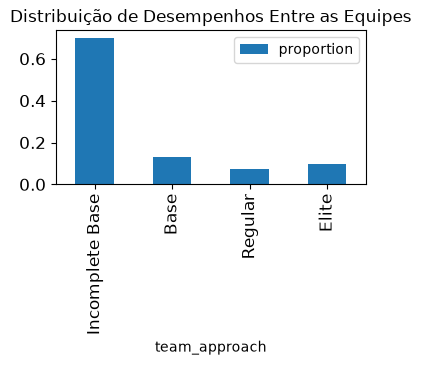

In [24]:
teamApproachPlot = dfTeamApproachN.plot(kind='bar', figsize=(4,2), title='Distribuição de Desempenhos Entre as Equipes',fontsize=12)

Analisando a trajetória adotada por um país de extremo sucesso na competição, a China, observamos como esse país consistentemente conseguiu perfomar como Elite, sem precisar desempenhar nas categorias intermediárias.

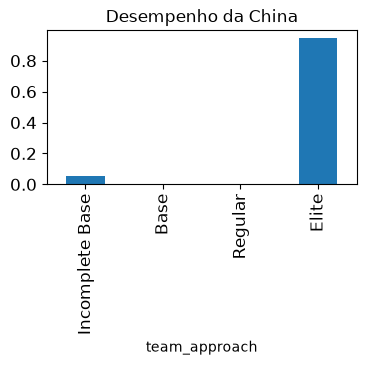

In [25]:
dfChinaApproach = data.loc[data['country'] == "People's Republic of China", "team_approach"].value_counts(sort = False, normalize = True)
chinaApproachPlot = dfChinaApproach.plot(kind='bar', figsize=(4,2), title='Desempenho da China',fontsize=12)

Já o Brasil se distribuiu conforme o gráfico abaixo. Perceba como o país já tem uma distribuição mais equilibrada com o que se espera da ordenação das abordagens, não tendo ainda se desempenhado como Elite.

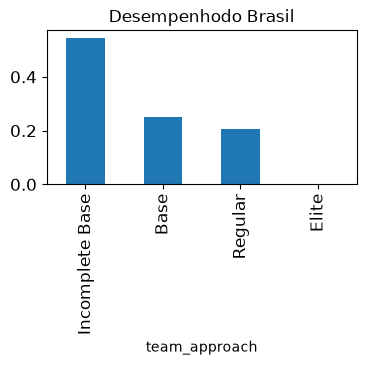

In [26]:
dfChinaApproach = data.loc[data['country'] == "Brazil", "team_approach"].value_counts(sort = False, normalize = True)
chinaApproachPlot = dfChinaApproach.plot(kind='bar', figsize=(4,2), title='Desempenhodo Brasil',fontsize=12)

Analisemos agora uma variável quantitativa. Na tabela abaixo, observamos como se distribui a proporção de meninas nas equipes, considerando os dados existentes. Cabe ressaltar que os dados anteriores a 2020 são parciais, nos quais nem todas as equipes possuem a informação da proporção de meninas. Percebe-se a enorme quantidade de equipes com até 1/6 de meninas na equipe.

In [27]:
x = data['female_proportion'].dropna()
femaleProportionIn = pd.cut(x, 
                      bins=np.linspace(0,1,7), 
                      labels=[
                          "[0/6 - 1/6]", 
                          "]1/6 - 2/6]", 
                          "]2/6 - 3/6]",
                          "]3/6 - 4/6]", 
                          "]4/6 - 5/6]", 
                          "]5/6 - 6/6]"
                      ], 
                      include_lowest=True,
                  )
display(pd.DataFrame(femaleProportionIn.value_counts(sort = False)))

,count
female_proportion,
[0/6 - 1/6],1127
]1/6 - 2/6],342
]2/6 - 3/6],95
]3/6 - 4/6],18
]4/6 - 5/6],2
]5/6 - 6/6],16


Abaixo, a distribuição normalizada e o gráfico de barras da distribuição:

,proportion
female_proportion,
[0/6 - 1/6],0.704375
]1/6 - 2/6],0.213750
]2/6 - 3/6],0.059375
]3/6 - 4/6],0.011250
]4/6 - 5/6],0.001250
]5/6 - 6/6],0.010000


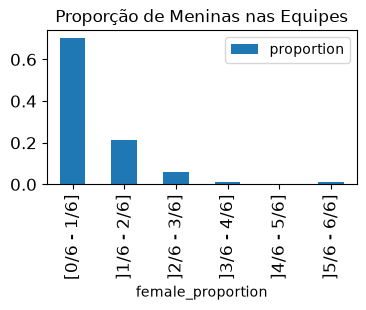

In [28]:
dfFemaleProportionIn = pd.DataFrame(femaleProportionIn.value_counts(sort = False, normalize = True))
display(dfFemaleProportionIn)
femaleProportionInPlot = dfFemaleProportionIn.plot(kind='bar', figsize=(4,2), title='Proporção de Meninas nas Equipes',fontsize=12)

## 1.2. Uma seção sobre gráficos univariados para ao menos uma variável de cada tipo (qualitativa nominal, qualitativa  ordinal, quantitativa discreta, quantitativa contínua);


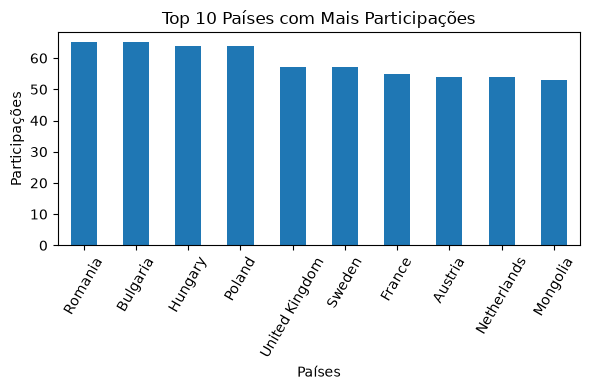

In [29]:
# VARIÁVEL QUALITATIVA NOMINAL

paises = data['country'].value_counts().head(10) #conta quantas vezes cada país aparece e pega os 10 primeiros
paisesplot = paises.plot(kind='bar', figsize=(6,4), title='Top 10 Países com Mais Participações',fontsize=10, rot= 60); #gera o gráfico de barras
#legendas dos eixos
plt.xlabel('Países');
plt.ylabel('Participações');

plt.tight_layout()
plt.show()

Aqui vemos os 10 páises que mais participam da competição, todos localizados na Europa.

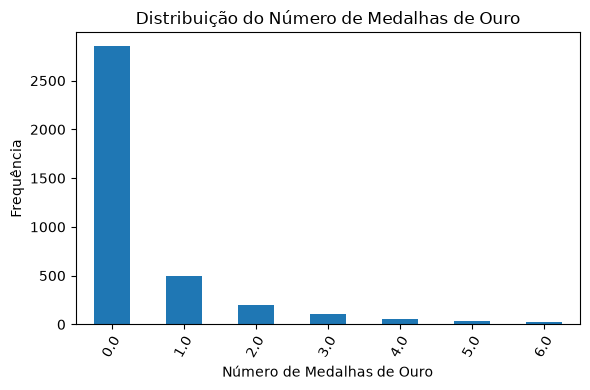

In [30]:
#VARIÁVEL QUANTITATIVA DISCRETA

ouros = data['awards_gold'].value_counts().sort_index() #conta quantas vezes cada número de medalhas de ouro aparece e ordena
ourosplot = ouros.plot(kind='bar', figsize=(6,4), title='Distribuição do Número de Medalhas de Ouro',fontsize=10, rot= 60); #gera o gráfico de barras
# legendas dos eixos
plt.xlabel('Número de Medalhas de Ouro');
plt.ylabel('Frequência');

plt.tight_layout()
plt.show()

Ao analisarmos o gráfico é possivel ver o imenso nível de dificuldade da IMO, onde a frêquencia de equipes que não conseguem nenhuma medalha de ouro na competição é imensamente maior do que as que conseguem pelo menos uma medalha.

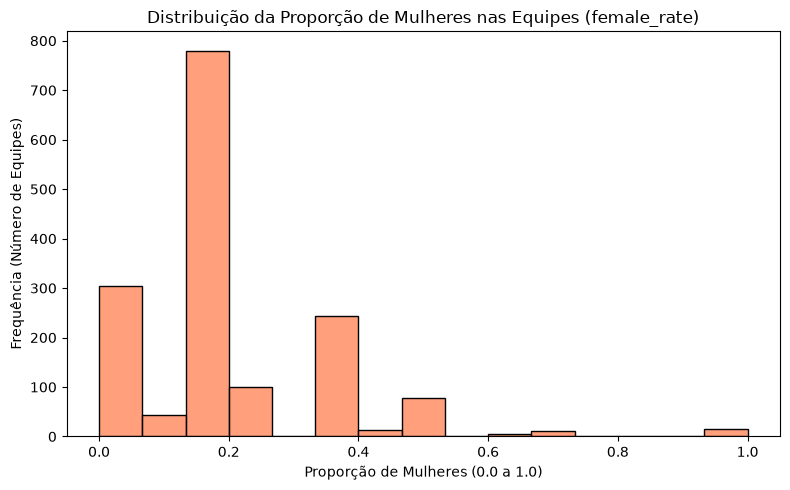

In [31]:
#QUANTITATIVA CONTÍNUA

plt.figure(figsize=(8, 5)) # tamanho da figura

sns.histplot(data["female_proportion"].dropna(), bins=15, color='coral', edgecolor='black') # gera o gráfico de histograma

#titulos
plt.title('Distribuição da Proporção de Mulheres nas Equipes (female_rate)', fontsize=12)
plt.xlabel('Proporção de Mulheres (0.0 a 1.0)', fontsize=10)
plt.ylabel('Frequência (Número de Equipes)', fontsize=10)

plt.tight_layout()
plt.show()

Como vimos no gráfico, a maioria absoluta das equipes tem uma proporção em torno de 0.0 a 0.2, ou seja, de 0 a 20% da equipe com participação feminina. O pico ocorre por volta do 0.1 e 0.15, o que corresponde a 1 mulher em uma equipe de 6 pessoas.

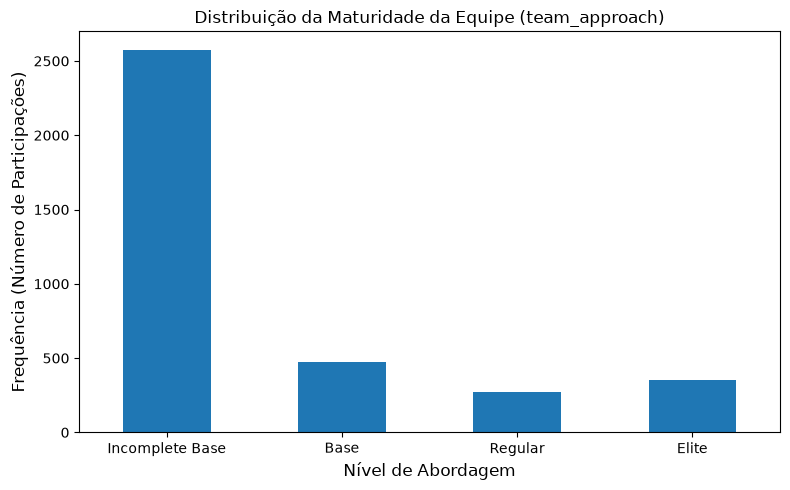

In [32]:
#QUALITATIVA ORDINAL

approach_counts = data["team_approach"].value_counts().sort_index() #conta quantas vezes cada nível de abordagem aparece e ordena

plt.figure(figsize=(8, 5)) # tamanho da figura

approachplot = approach_counts.plot(kind='bar', title= 'Distribuição da Maturidade da Equipe (team_approach)', rot=0) # gera o gráfico de barras
#legenda
plt.xlabel('Nível de Abordagem', fontsize=12)
plt.ylabel('Frequência (Número de Participações)', fontsize=12)


plt.tight_layout()
plt.show()

Ao analisarmos o gráfico, vemos que o nivel de abordagem com 0 maturidade é extremamente grande, o que indica que a imensa maioria das equipes não conseguem resolver de forma consistente nem as duas questões "fáceis" da prova. Com o nível de maturidade 3 ocorre um fenomeno interessante, cusiosamente há mais ocorrencias no nivel 3 do que no nível 2. Isso indica que, quando um páis atinge maturidade de teinamento para quase gabaritar as fáceis e resolver as médias, os alunos dessa equipe também tem nível e preparo para pontuar nas questões mais difíceis da competição.

1.3. Uma seção sobre análise bivariada, com ao menos uma distribuição de frequências e uma figura bivariadas;


In [33]:
top_10_ouro = data.groupby('country')['awards_gold'].sum().sort_values(ascending=False).head(10)

display(top_10_ouro)

country
People's Republic of China             185.0
United States of America               151.0
Russian Federation                     106.0
Republic of Korea                       95.0
Hungary                                 88.0
Romania                                 86.0
Union of Soviet Socialist Republics     77.0
Vietnam                                 69.0
Bulgaria                                57.0
United Kingdom                          56.0
Name: awards_gold, dtype: float64

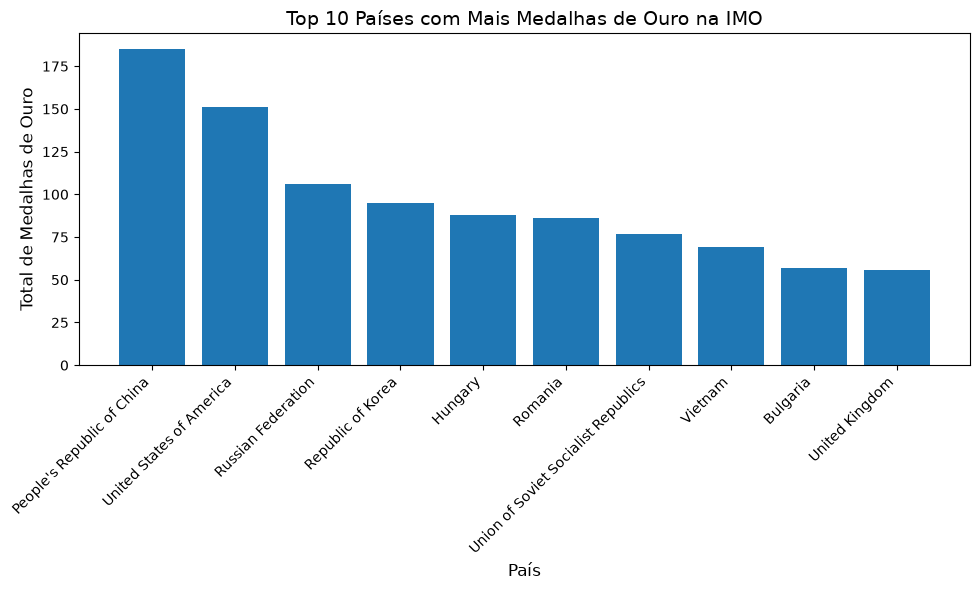

In [34]:
plt.figure(figsize=(10, 6))
barras = plt.bar(top_10_ouro.index, top_10_ouro.values)

plt.title('Top 10 Países com Mais Medalhas de Ouro na IMO', fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Total de Medalhas de Ouro', fontsize=12)
           
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [35]:
br = data.query("country == 'Brazil'").copy()
medalhas = ["awards_gold", "awards_silver", "awards_bronze"]
resumo = br[medalhas].agg(["mean", "median"])

moda = br[medalhas].mode().iloc[0]
resumo.loc["mode"] = moda

resumo


,awards_gold,awards_silver,awards_bronze
mean,0.333333,1.288889,2.022222
median,0.000000,1.000000,2.000000
mode,0.000000,0.000000,1.000000


In [36]:
br['decada'] = (br['year'] // 10) * 10
br

resumo_pais = br.groupby('decada')[medalhas].agg(
    ['count','mean','median']
)

ordenado = resumo_pais.sort_index(ascending=False)
ordenado

awards_gold                  awards_silver             awards_bronze  \
             count      mean median         count mean median         count   
decada                                                                        
2020             5  1.000000    1.0             5  2.6    2.0             5   
2010            10  0.200000    0.0            10  2.4    2.5            10   
2000            10  0.200000    0.0            10  1.8    1.5            10   
1990            10  0.300000    0.0            10  0.3    0.0            10   
1980             9  0.333333    0.0             9  0.0    0.0             9   
1970             1  0.000000    0.0             1  0.0    0.0             1   

                         
            mean median  
decada                   
2020    2.000000    2.0  
2010    2.300000    2.5  
2000    3.000000    3.0  
1990    1.400000    1.0  
1980    1.555556    2.0  
1970    0.000000    0.0

# 1.4 medidas de posicao central

## 1.4.1 - Distribuição geral das medalhas

A partir dos dados gerais observamos algumas tendencias, a media de medalhas é inferior a uma medalha *ouro(0,47)* e *prata(0,96)* sendo *bronze(1,42).* As medianas e modas de ouro e prata convergem para 0, indicando que pela mediana pelo menos metade dos registros validos nao ganhou medalhas e pela moda a maior parter zerou na categoria. Posteriomente, investigaremos valores que podem ter influenciado as nossa medidas.

In [37]:
medalhas_resumo = data[medalhas].agg(["count", "mean", "median",'std'])
display(medalhas_resumo)

,awards_gold,awards_silver,awards_bronze
count,3778.000000,3778.000000,3778.000000
mean,0.470619,0.960296,1.417152
median,0.000000,0.000000,1.000000
std,1.045590,1.285347,1.365307


In [38]:
data[medalhas].mode()

,awards_gold,awards_silver,awards_bronze
0,0.0,0.0,0.0


A análise da frequência de medalhas evidencia uma concentração de registros com valor zero, principalmente nas categorias ouro e prata. Aproximadamente 75,5% dos registros válidos não apresentam medalhas de ouro, enquanto 53,7% não apresentam medalhas de prata. Na categoria bronze, essa proporção é de aproximadamente 33,7%. 

Essa densidade de valores nulos contribui para explicar os resultados anteriores, a mediana do ouro e prata, por exemplo, indicam valores iguais a zero. Além disso, a discrepancia entre os valores maximos e minimos para alem do que ja foi discuido pode indicar uma assimetria positiva.

In [39]:
filtro = data["awards_gold"].isin([0.0,6.0])
data[filtro]['awards_gold'].value_counts()

awards_gold
0.0    2853
6.0      25
Name: count, dtype: int64

In [40]:
for coluna in medalhas:
    valores = data[coluna].dropna()
    maximo = (valores == 6).sum()  

    display(f"{coluna}: {maximo} maximo (de {len(valores)} registros)")


'awards_gold: 25 maximo (de 3778 registros)'

'awards_silver: 4 maximo (de 3778 registros)'

'awards_bronze: 11 maximo (de 3778 registros)'

In [41]:
for coluna in medalhas:
    valores = data[coluna].dropna()
    total_zeros = (valores == 0).sum()  

    display(f"{coluna}: {total_zeros} zeros (de {len(valores)} registros)")

   

'awards_gold: 2853 zeros (de 3778 registros)'

'awards_silver: 2029 zeros (de 3778 registros)'

'awards_bronze: 1274 zeros (de 3778 registros)'

In [42]:
for coluna in medalhas:
    valores = data[coluna].dropna()
    percentual_zeros = valores.isin([0]).mean() * 100

    display(f"{coluna}: {percentual_zeros:.2f}% de zeros")

'awards_gold: 75.52% de zeros'

'awards_silver: 53.71% de zeros'

'awards_bronze: 33.72% de zeros'

## 1.4.2 — Medidas de posição central por pais

As medidas de posicao central do top 10 com pelo menos 10 participacoes nos indicam que, no topo a media e mediana sao proximas em valores, diferindo entre perfis:
- media menor que a mediana = onde parece ter um influencia maior de valores pequenos

- mediana menor que a media = resultados frequentes entre valores medios e alguns excepcionais que aumentam a media.

- algumas diferencas pequenas como a dos EUA podem indicar simetria, a partir de valores adicionais de dispersao. 

In [43]:
pais = data.groupby('country')['awards_gold'].agg(n='count', media='mean', mediana='median')
pais['media_menos_mediana'] = pais['media'] - pais['mediana']

pais = pais[pais['n'] >= 10].sort_values(['mediana', 'media'], ascending=False)
display(pais.head(10))

,n,media,mediana,media_menos_mediana
country,,,,
People's Republic of China,39,4.743590,5.0,-0.256410
Russian Federation,30,3.533333,4.0,-0.466667
United States of America,50,3.020000,3.0,0.020000
Union of Soviet Socialist Republics,29,2.655172,3.0,-0.344828
Republic of Korea,37,2.567568,2.0,0.567568
Democratic People's Republic of Korea,12,1.833333,2.0,-0.166667
Vietnam,48,1.437500,1.0,0.437500
Taiwan,33,1.393939,1.0,0.393939
Hungary,64,1.375000,1.0,0.375000


## 1.4.3 - resultados do brasil

O Brasil participou da competição 45 vezes, Vamos analisar seu desempenho em relação ao número de medalhas obtidas. Em ouro, a média é de 0,33 por participação, e a mediana e a moda são 0: na maior parte das edições, a equipe não conquistou ouro, e o máximo em uma única edição foi 2, com um valor abaixo da média geral (0,47). Em prata, a média é 1,29 e a mediana, 1, acima da média geral (0,96). Em bronze, a média é 2,02 e a mediana, 2, também acima da média geral (1,42), embora a moda seja 1, ou seja, o valor mais frequente fica abaixo do centro da distribuição. Assim, o desempenho típico do Brasil se concentra em medalhas de prata e bronze, com ouro ocasional.

In [44]:
br = data.query("country == 'Brazil'").copy()
resumo = br[medalhas].agg(["mean", "median",'max','sum'])

moda = br[medalhas].mode().iloc[0]
resumo.loc["mode"] = moda

resumo


,awards_gold,awards_silver,awards_bronze
mean,0.333333,1.288889,2.022222
median,0.000000,1.000000,2.000000
max,2.000000,5.000000,6.000000
sum,15.000000,58.000000,91.000000
mode,0.000000,0.000000,1.000000


In [45]:
br.shape

(45, 20)

Em 1970, há apenas uma participação, o que dificulta qualquer interpretação dos resultados. Em 1980, o desempenho é extremamente baixo, com as melhores médias concentradas nas medalhas de bronze. Na década de 1990, observa-se uma pequena melhora nos resultados de prata e uma redução na média de medalhas de bronze, enquanto a média de ouros permanece baixa.

Já nos anos 2000, há uma melhora significativa nas médias de prata e bronze, embora os resultados em ouro continuem baixos. Por fim, na década de 2020, observa-se uma melhora expressiva nas métricas de ouro, sendo a primeira década analisada a apresentar esse avanço. Entretanto, é importante considerar que os dados abrangem apenas cinco anos dessa década.

No conjunto, os resultados sugerem uma evolução gradual, com avanços nas medalhas de prata e bronze e uma melhora mais recente no desempenho em ouro.

In [46]:
br['decada'] = (br['year'] // 10) * 10

resumo_pais = br.groupby('decada')[medalhas].agg(
    ['count','mean','median']
)

ordenado = resumo_pais.sort_index(ascending=False)
ordenado

awards_gold                  awards_silver             awards_bronze  \
             count      mean median         count mean median         count   
decada                                                                        
2020             5  1.000000    1.0             5  2.6    2.0             5   
2010            10  0.200000    0.0            10  2.4    2.5            10   
2000            10  0.200000    0.0            10  1.8    1.5            10   
1990            10  0.300000    0.0            10  0.3    0.0            10   
1980             9  0.333333    0.0             9  0.0    0.0             9   
1970             1  0.000000    0.0             1  0.0    0.0             1   

                         
            mean median  
decada                   
2020    2.000000    2.0  
2010    2.300000    2.5  
2000    3.000000    3.0  
1990    1.400000    1.0  
1980    1.555556    2.0  
1970    0.000000    0.0

## 1.4.4 - Análise do desempenho por questão

Optamos por focar essa análise sobre os 36 anos mais recentes (1990 a 2024) porque a pontuacao das questões no periodo anterior era constituida de forma distinta. Assim, podemos analisar melhor os nossos dados em relacão a essa metrica especifica.

Inicialmente, foram calculadas as medidas descritivas das pontuações das questões P1 a P6, com p7 não participando da análise pelo fato de que a IMO consiste em apenas 6 problemas, com o objetivo de observar o comportamento geral do desempenho ao longo das edições e países presentes na base. A comparação das médias permite identificar quais questões apresentaram pontuações médias mais elevadas.

Em seguida, as médias foram agrupadas por país para identificar aqueles que apresentaram melhor desempenho médio em cada questão. Para evitar que países com poucas participações fossem comparados diretamente com países que possuem mais registros, foi estabelecido um número mínimo de observações por país.

Os resultados permitem descrever diferenças de desempenho entre questões e países. Entretanto, a média isolada não permite concluir que uma questão é mais difícil do que outra, por isso foi considerado também uma comparação com a pontuação máxima possível.

In [47]:
ultimos_30 = data['year'] >= 1990
data_ultimos_anos = data[ultimos_30]

In [48]:
data_ultimos_anos['country'].nunique()

139

### p1

A pontuação média do Problema 1 a partir desse periodo é 24,97 em 42 possiveis, indicando desempenho moderado. A Comunidade dos Estados Independentes tem uma pontuacao media de 41 pontos para esse problema. No entanto, isso é baseado em uma única participação em 1992, periodo de colapso da união soviética, o que enviesa sua média.

In [49]:
round(data_ultimos_anos['p1'].agg(['mean','median','max','min']),2) 

mean      24.97
median    27.00
max       42.00
min        0.00
Name: p1, dtype: float64

In [50]:
resultado_p1 =  data_ultimos_anos.groupby('country')['p1'].agg(['count', 'mean'])
resultado_p1 = resultado_p1.sort_values(['mean','count'],ascending=False)

resultado_p1 = resultado_p1.query("count >= 5")
resultado_p1.head(10)

,count,mean
country,,
People's Republic of China,34,40.647059
Russian Federation,30,39.500000
United States of America,35,39.400000
Democratic People's Republic of Korea,12,39.250000
Hungary,35,38.971429
Bulgaria,35,38.200000
Taiwan,33,38.030303
Serbia,19,37.842105
Republic of Korea,35,37.485714


### p2

A pontuação média do Problema 2 ao longo do período de 36 anos é 14,24 em 42,0, indicando desempenho relativamente baixo. Entre todos os países, China tem a maior média para o Problema 2, aproximadamente 38,65.

In [51]:
round(data_ultimos_anos['p2'].agg(['mean','median','max','min']),2) 

mean      14.24
median    10.00
max       42.00
min        0.00
Name: p2, dtype: float64

In [52]:
resultado_p2 =  data_ultimos_anos.groupby('country')['p2'].agg(['count', 'mean'])
resultado_p2 = resultado_p2.sort_values(['mean','count'],ascending=False)

resultado_p2 = resultado_p2.query("count >= 5")
resultado_p2.head(10)

,count,mean
country,,
People's Republic of China,34,38.647059
United States of America,35,34.257143
Russian Federation,30,33.966667
Republic of Korea,35,33.428571
Vietnam,35,31.914286
Romania,35,30.514286
Taiwan,33,29.787879
Islamic Republic of Iran,35,29.628571
Democratic People's Republic of Korea,12,29.250000


### p3

A pontuação média do Problema 3 ao longo do período de 30 anos é de 5,49 em 42, indicando desempenho muito baixo. Entre todos os países, novamente a China lidera com a maior média de aproximadamente 28,29, enquanto os outros países têm médias relativamente menores. Isso sugere que a maioria dos países Tem muita dificuldade com esse problema.

In [53]:
round(data_ultimos_anos['p3'].agg(['mean','median','max','min']),2) 

mean       5.49
median     1.00
max       42.00
min        0.00
Name: p3, dtype: float64

In [54]:
resultado_p3 =  data_ultimos_anos.groupby('country')['p3'].agg(['count', 'mean'])
resultado_p3 = resultado_p3.sort_values(['mean','count'],ascending=False)

resultado_p3 = resultado_p3.query("count >= 5")
resultado_p3.head(10)

,count,mean
country,,
People's Republic of China,34,28.294118
United States of America,35,22.800000
Russian Federation,30,22.133333
Republic of Korea,35,19.200000
Romania,35,15.000000
Vietnam,35,14.914286
Democratic People's Republic of Korea,12,14.833333
Hungary,35,14.342857
Japan,35,13.742857


### p4

A pontuação média do Problema 4 ao longo do período de 30 anos é 23,04 em 42, indicando desempenho moderado. A China tem a maior média pontuação para esse problema em torno de 40,74, seguida de perto pela Rússia e pelo EUA, cada uma com uma média de aproximadamente 39,33; 39,14.

In [55]:
round(data_ultimos_anos['p4'].agg(['mean','median','max','min']),2) 

mean      23.04
median    24.00
max       42.00
min        0.00
Name: p4, dtype: float64

In [56]:
resultado_p4 =  data_ultimos_anos.groupby('country')['p4'].agg(['count', 'mean'])
resultado_p4 = resultado_p4.sort_values(['mean','count'],ascending=False)

resultado_p4 = resultado_p4.query("count >= 5")
resultado_p4.head(10)

,count,mean
country,,
People's Republic of China,34,40.735294
Russian Federation,30,39.333333
United States of America,35,39.142857
Islamic Republic of Iran,35,38.028571
Taiwan,33,37.424242
Romania,35,37.257143
Republic of Korea,35,37.142857
Bulgaria,35,36.742857
Serbia,19,35.894737


### p5

A pontuação média para o Problema 5 ao longo do período de 30 anos é 12,79 em 42, indicando desempenho relativamente baixo. China lidera o indice novamente com 36,88.

In [57]:
round(data_ultimos_anos['p5'].agg(['mean','median','max','min']),2) 

mean      12.79
median     9.00
max       42.00
min        0.00
Name: p5, dtype: float64

In [58]:
resultado_p5 =  data_ultimos_anos.groupby('country')['p5'].agg(['count', 'mean'])
resultado_p5 = resultado_p5.sort_values(['mean','count'],ascending=False)

resultado_p5 = resultado_p5.query("count >= 5")
resultado_p5.head(10)

,count,mean
country,,
People's Republic of China,34,36.882353
United States of America,35,32.371429
Russian Federation,30,32.266667
Republic of Korea,35,29.971429
Democratic People's Republic of Korea,12,29.083333
Vietnam,35,28.600000
Romania,35,27.000000
Islamic Republic of Iran,35,26.885714
Taiwan,33,26.757576


### p6 

A pontuação média do Problema 6 ao longo do período de 30 anos é 3,98 em 42, indicando desempenho extremamente baixo. A China lidera com uma média pontuação de 25,53, seguida pelos EUA com 20,60. Nenhum outro país alcança um Pontuação média acima de 20, destacando o alto nível de dificuldade associado ao Problema 6.

In [59]:
round(data_ultimos_anos['p6'].agg(['mean','median','max','min']),2) 

mean       3.98
median     0.00
max       42.00
min        0.00
Name: p6, dtype: float64

In [60]:
resultado_p6 =  data_ultimos_anos.groupby('country')['p6'].agg(['count', 'mean'])
resultado_p6 = resultado_p6.sort_values(['mean','count'],ascending=False)

resultado_p6 = resultado_p6.query("count >= 5")
resultado_p6.head(10)

,count,mean
country,,
People's Republic of China,34,25.529412
United States of America,35,20.600000
Russian Federation,30,17.233333
Republic of Korea,35,14.057143
Bulgaria,35,12.514286
Hungary,35,12.028571
Romania,35,11.942857
Japan,35,11.800000
Islamic Republic of Iran,35,10.542857
